In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Smart_Farming_Crop_Yield_2024.csv to Smart_Farming_Crop_Yield_2024.csv


In [ ]:
df = pd.read_csv('Smart_Farming_Crop_Yield_2024.csv')

(500, 5)


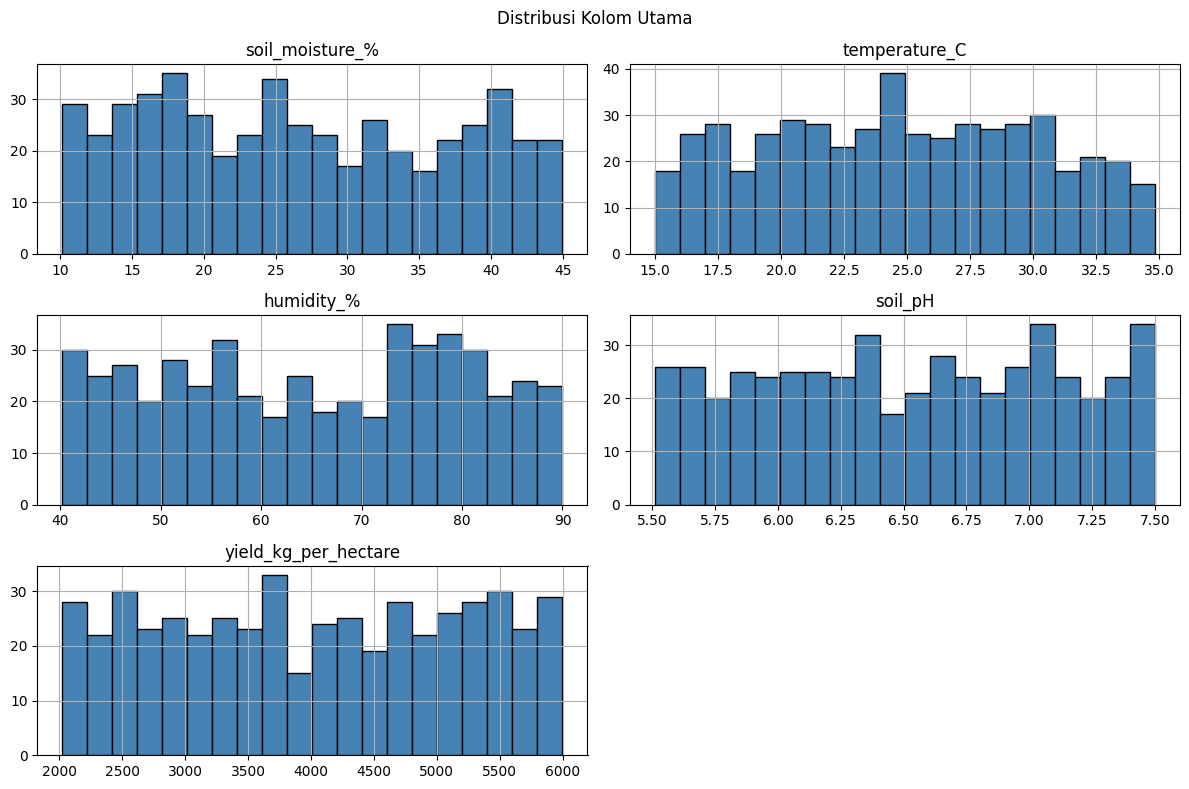

In [ ]:
# Pilih kolom utama
main_cols = ['soil_moisture_%', 'temperature_C', 'humidity_%', 'soil_pH', 'yield_kg_per_hectare']
df_main = df[main_cols]

# Preview
print(df_main.shape)
df_main.head()

# Statistik deskriptif
df_main.describe()

# Cek missing values
df_main.isnull().sum()

# Distribusi masing-masing kolom
df_main.hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Kolom Utama')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Handle Missing Values
df_main.fillna(df_main.median(), inplace=True)

# 2. Handle Outliers dengan IQR
for col in main_cols:
    Q1 = df_main[col].quantile(0.25)
    Q3 = df_main[col].quantile(0.75)
    IQR = Q3 - Q1
    df_main = df_main[
        (df_main[col] >= Q1 - 1.5 * IQR) &
        (df_main[col] <= Q3 + 1.5 * IQR)
    ]

# 3. Format datetime (dari df asli, untuk keperluan time series)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month']     = df['timestamp'].dt.to_period('M')

print("Data setelah cleaning:", df_main.shape)
df_main.describe()

Data setelah cleaning: (500, 5)


/tmp/ipykernel_1234/3176420858.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_main.fillna(df_main.median(), inplace=True)


,soil_moisture_%,temperature_C,humidity_%,soil_pH,yield_kg_per_hectare
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,26.750140,24.675740,65.194460,6.523980,4032.92694
std,10.150053,5.348899,14.642849,0.585558,1174.43304
min,10.160000,15.000000,40.230000,5.510000,2023.56000
25%,17.890000,20.295000,51.865000,6.030000,2994.82000
50%,25.855000,24.655000,65.685000,6.530000,4071.69000
75%,36.022500,29.090000,77.995000,7.040000,5062.11000
max,44.980000,34.840000,90.000000,7.500000,5998.29000


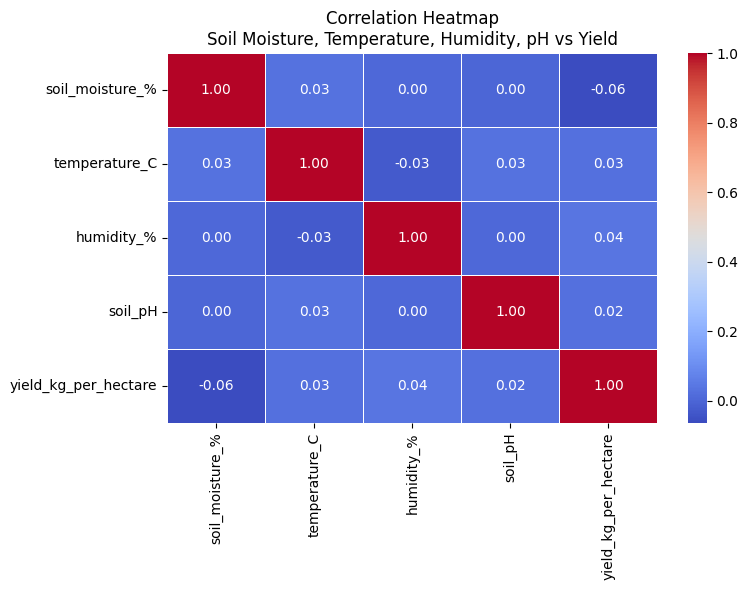

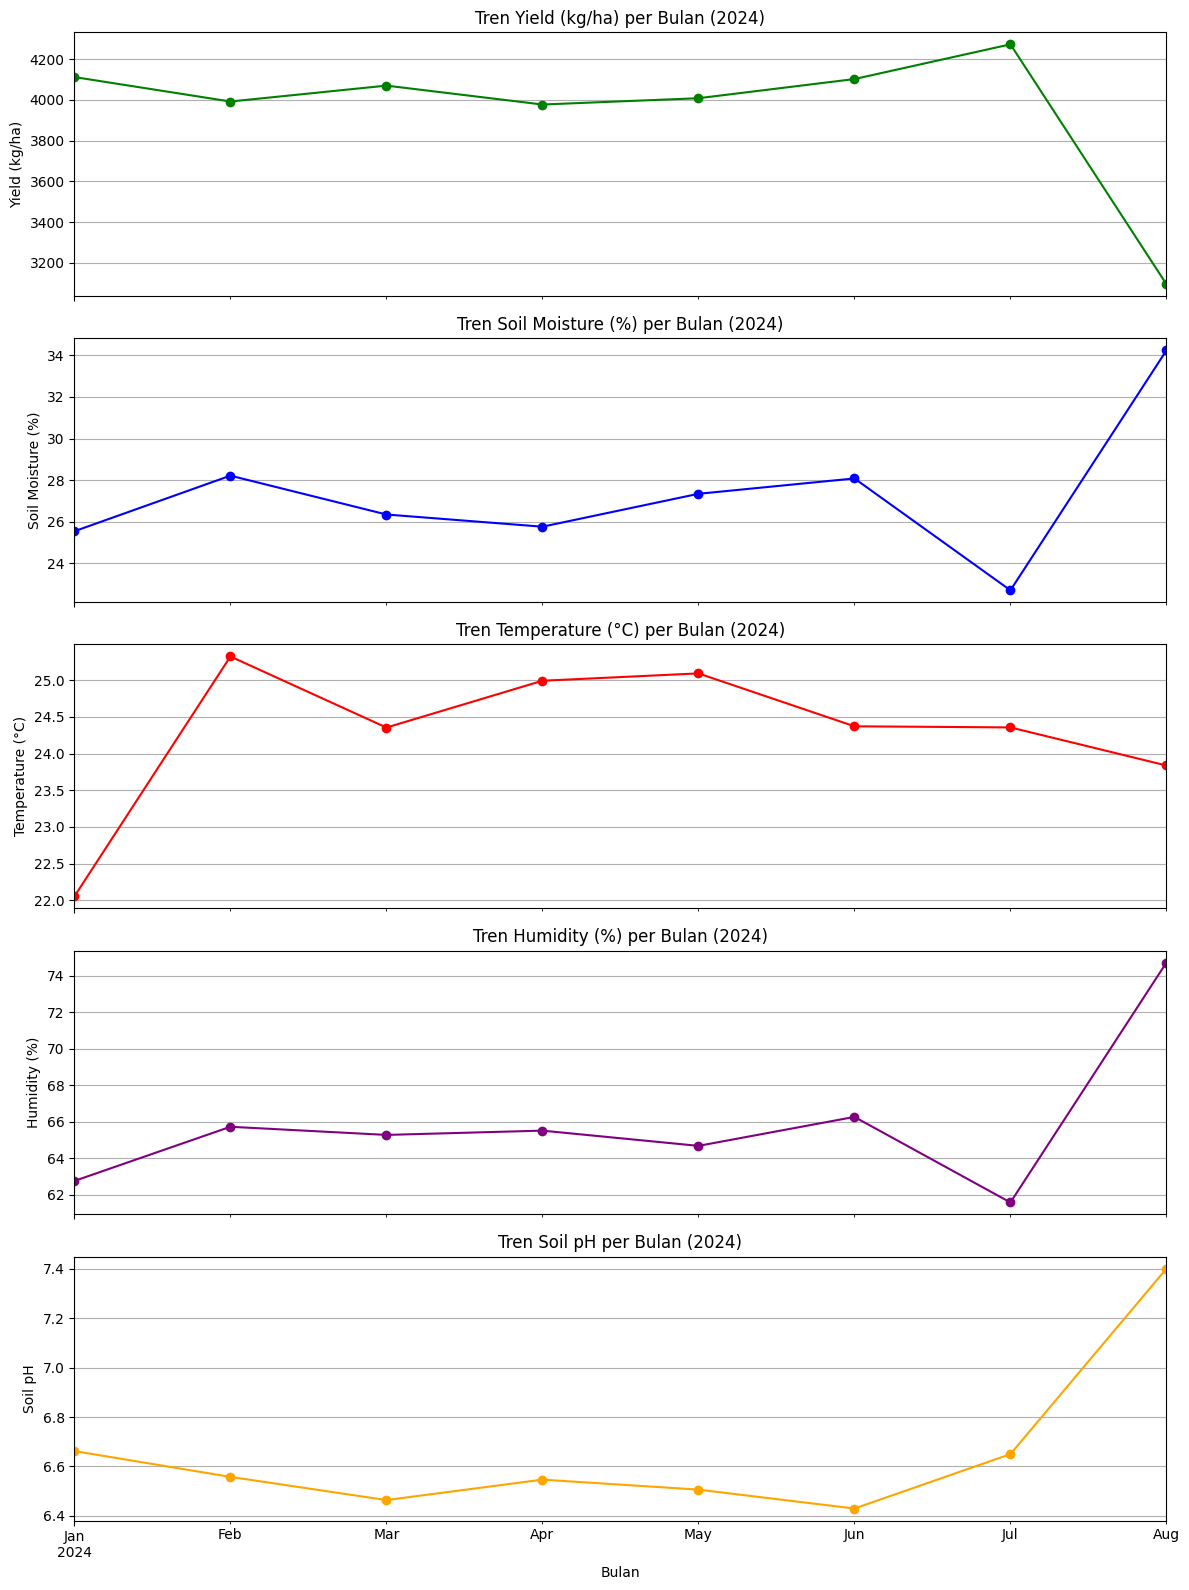

In [ ]:
# --- CORRELATION HEATMAP ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_main.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap\nSoil Moisture, Temperature, Humidity, pH vs Yield')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# --- TIME SERIES TREND (Yield per Bulan) ---
df_ts = df[['timestamp', 'yield_kg_per_hectare',
            'soil_moisture_%', 'temperature_C',
            'humidity_%', 'soil_pH']].copy()
df_ts['month'] = df_ts['timestamp'].dt.to_period('M')

monthly = df_ts.groupby('month')[
    ['yield_kg_per_hectare', 'soil_moisture_%',
     'temperature_C', 'humidity_%', 'soil_pH']
].mean()

# Plot semua tren dalam satu figure
fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
cols_plot = {
    'yield_kg_per_hectare' : ('green',  'Yield (kg/ha)'),
    'soil_moisture_%'      : ('blue',   'Soil Moisture (%)'),
    'temperature_C'        : ('red',    'Temperature (°C)'),
    'humidity_%'           : ('purple', 'Humidity (%)'),
    'soil_pH'              : ('orange', 'Soil pH'),
}

for ax, (col, (color, label)) in zip(axes, cols_plot.items()):
    monthly[col].plot(ax=ax, marker='o', color=color)
    ax.set_title(f'Tren {label} per Bulan (2024)')
    ax.set_ylabel(label)
    ax.grid(True)

plt.xlabel('Bulan')
plt.tight_layout()
plt.savefig('timeseries_trend.png')
plt.show()

In [ ]:
# Gabungkan kolom utama yang sudah bersih + timestamp
df_clean = df_main.copy()
df_clean['timestamp'] = df.loc[df_main.index, 'timestamp']

# Simpan
df_clean.to_csv('cleaned_data.csv', index=False)
print("File berhasil disimpan!")

# Verifikasi
pd.read_csv('cleaned_data.csv').head()

File berhasil disimpan!


,soil_moisture_%,temperature_C,humidity_%,soil_pH,yield_kg_per_hectare,timestamp
0,35.95,17.79,77.03,5.99,4408.07,2024-03-19
1,19.74,30.18,61.13,7.24,5389.98,2024-04-21
2,29.32,27.37,68.87,7.16,2931.16,2024-02-28
3,17.33,33.73,70.46,6.03,4227.80,2024-05-14
4,19.37,33.86,55.73,5.92,4979.96,2024-04-13


In [ ]:
from google.colab import files
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from datetime import datetime, timedelta

df = pd.read_csv('Smart_Farming_Crop_Yield_2024.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

total = len(df)
total_cells = df.size

# ACCURACY = 1 - (missing / total cells)
missing = df.isnull().sum().sum()
accuracy = 1 - (missing / total_cells)

# COMPLETENESS = non-null / total cells
non_null = total_cells - missing
completeness = non_null / total_cells

# TIMELINESS = % data dalam 30 hari terakhir
cutoff = df['timestamp'].max() - timedelta(days=30)
timeliness = len(df[df['timestamp'] >= cutoff]) / total

print("=" * 40)
print("   DATA QUALITY SCORE REPORT")
print("=" * 40)
print(f"Total Rows       : {total}")
print(f"Missing Values   : {missing}")
print(f"Accuracy         : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Completeness     : {completeness:.4f} ({completeness*100:.2f}%)")
print(f"Timeliness       : {timeliness:.4f} ({timeliness*100:.2f}%)")
print("-" * 40)
overall = (accuracy + completeness + timeliness) / 3
print(f"Overall DQ Score : {overall*100:.2f}%")
print("=" * 40)

   DATA QUALITY SCORE REPORT
Total Rows       : 500
Missing Values   : 280
Accuracy         : 0.9745 (97.45%)
Completeness     : 0.9745 (97.45%)
Timeliness       : 0.0140 (1.40%)
----------------------------------------
Overall DQ Score : 65.44%
